# Лабораторна робота 6
#### Розробка системи підтримки прийняття рішень з використанням агентних технологій для моделювання та аналізу складних бізнес сценаріїв

## Сценарій: віртуальний асистент який дає поради як вдягнутис

In [12]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

import skfuzzy as fuzz
from skfuzzy import control as ctrl

import gradio as gr

## 1. Агенти
### 1.1 WeatherAgent - визначає прогноз погоди

In [13]:
class WeatherAgent:

    def get_weather_data(self, temperature, humidity, rain, wind):

        data = {
            "temperature": temperature,
            "humidity": humidity,
            "rain": rain,
            "wind": wind
        }

        return data

### 1.2 DecisionAgent - рекомендаційна система

In [14]:
class DecisionAgent:

    def __init__(self):

        self.temperature = ctrl.Antecedent(np.arange(-10, 41, 1),'temperature')
        self.humidity = ctrl.Antecedent( np.arange(0, 101, 1),'humidity' )
        self.rain = ctrl.Antecedent(np.arange(0, 101, 1), 'rain' )
        self.wind = ctrl.Antecedent(np.arange(0, 51, 1), 'wind' )

        self.clothing = ctrl.Consequent( np.arange(0, 11, 1),'clothing')

        self.temperature['cold'] = fuzz.trimf(self.temperature.universe, [-10, -10, 10])
        self.temperature['mild'] = fuzz.trimf(self.temperature.universe, [5, 18, 28])
        self.temperature['hot'] = fuzz.trimf(self.temperature.universe, [20, 40, 40])

        self.humidity['low'] = fuzz.trimf(self.humidity.universe, [0, 0, 40])
        self.humidity['medium'] = fuzz.trimf(self.humidity.universe, [30, 50, 70])
        self.humidity['high'] = fuzz.trimf(self.humidity.universe, [60, 100, 100])

        self.rain['no'] = fuzz.trimf(self.rain.universe, [0, 0, 30])
        self.rain['medium'] = fuzz.trimf(self.rain.universe, [20, 50, 80])
        self.rain['high'] = fuzz.trimf(self.rain.universe, [60, 100, 100])

        self.wind['low'] = fuzz.trimf(self.wind.universe, [0, 0, 15])
        self.wind['medium'] = fuzz.trimf(self.wind.universe, [10, 20, 30])
        self.wind['high'] = fuzz.trimf(self.wind.universe, [25, 50, 50])

        self.clothing['very_light'] = fuzz.trimf(self.clothing.universe, [0, 0, 2])
        self.clothing['light'] = fuzz.trimf(self.clothing.universe, [1, 2.5, 4])
        self.clothing['light_medium'] = fuzz.trimf(self.clothing.universe, [3, 4.5, 6])
        self.clothing['medium'] = fuzz.trimf(self.clothing.universe, [5, 6.5, 8])
        self.clothing['warm'] = fuzz.trimf(self.clothing.universe, [7, 8.5, 10])
        self.clothing['very_warm'] = fuzz.trimf(self.clothing.universe, [9, 10, 10])

        self.rule1 = ctrl.Rule(self.temperature['cold'], self.clothing['warm'])
        self.rule2 = ctrl.Rule(self.temperature['mild'] & self.rain['medium'], self.clothing['medium'])
        self.rule3 = ctrl.Rule(self.temperature['hot'] & self.rain['no'], self.clothing['very_light'])
        self.rule4 = ctrl.Rule(self.wind['high'] & self.temperature['mild'], self.clothing['warm'])
        self.rule5 = ctrl.Rule(self.rain['high'], self.clothing['very_warm'])
        self.rule6 = ctrl.Rule(self.humidity['high'] & self.temperature['hot'], self.clothing['light_medium'])
        self.rule7 = ctrl.Rule(self.temperature['mild'] & self.rain['no'], self.clothing['light_medium'])
        self.rule8 = ctrl.Rule(self.temperature['hot'] & self.wind['high'], self.clothing['medium'])
        self.rule9 = ctrl.Rule(self.humidity['low'] & self.temperature['hot'], self.clothing['very_light'])
        self.rule10 = ctrl.Rule(self.wind['low'] & self.temperature['cold'], self.clothing['warm'])
        self.rule11 = ctrl.Rule(self.humidity['medium'], self.clothing['medium'])

        self.rule12 = ctrl.Rule(self.temperature['cold'] & self.wind['high'], self.clothing['very_warm'])
        self.rule13 = ctrl.Rule(self.temperature['cold'] & self.rain['high'], self.clothing['very_warm'])
        self.rule14 = ctrl.Rule(self.temperature['hot'] & self.humidity['high'], self.clothing['light'])
        self.rule15 = ctrl.Rule(self.temperature['hot'] & self.rain['medium'], self.clothing['light_medium'])
        self.rule16 = ctrl.Rule(self.temperature['mild'] & self.wind['low'], self.clothing['light_medium'])
        self.rule17 = ctrl.Rule(self.temperature['mild'] & self.humidity['high'], self.clothing['medium'])
        self.rule18 = ctrl.Rule(self.wind['high'] & self.rain['high'], self.clothing['very_warm'])
        self.rule19 = ctrl.Rule(self.wind['medium'] & self.temperature['cold'], self.clothing['warm'])
        self.rule20 = ctrl.Rule(self.wind['medium'] & self.temperature['hot'], self.clothing['light_medium'])
        self.rule21 = ctrl.Rule(self.humidity['low'] & self.rain['no'], self.clothing['light'])
        self.rule22 = ctrl.Rule(self.humidity['high'] & self.rain['high'], self.clothing['warm'])
        self.rule23 = ctrl.Rule(self.temperature['hot'] & self.wind['low'], self.clothing['very_light'])
        self.rule24 = ctrl.Rule(self.temperature['mild'] & self.wind['high'] & self.rain['medium'], self.clothing['warm'])
        self.rule25 = ctrl.Rule(self.temperature['cold'] & self.humidity['high'], self.clothing['very_warm'])

        self.control_system = ctrl.ControlSystem([
            self.rule1, self.rule2, self.rule3, self.rule4, self.rule5, self.rule6, 
            self.rule7, self.rule8, self.rule9, self.rule10, self.rule11, self.rule12,
            self.rule13, self.rule14, self.rule15, self.rule16, self.rule17, self.rule18, 
            self.rule19, self.rule20, self.rule21, self.rule22, self.rule23, self.rule24, self.rule25])

        self.simulator = ctrl.ControlSystemSimulation( self.control_system )


    def make_decision(self, weather_data):

        self.simulator.input['temperature'] = weather_data['temperature']
        self.simulator.input['humidity'] = weather_data['humidity']
        self.simulator.input['rain'] = weather_data['rain']
        self.simulator.input['wind'] = weather_data['wind']

        self.simulator.compute()

        result = self.simulator.output['clothing']

        temperature = weather_data['temperature']
        rain = weather_data['rain']
        wind = weather_data['wind']
        humidity = weather_data['humidity']

        if result < 2:

            recommendation = f"Дуже тепла погода. Рекомендовано вдягнути футболку або майку, шорти або легкі штани, легке взуття. Парасоля не потрібна. Вітер слабкий або помірний "

        elif result < 4:

            recommendation = f" Легка та комфортна погода. Рекомендовано вдягнути футболку або легку кофту, джинси або спортивні штани, кросівкию. Можлива легка вологість. Парасоля зазвичай не потрібна"

        elif result < 6:

            recommendation = f" Помірна погода. Рекомендовано вдягнути худі або легку куртку, джинси, закрите взуття. Можливий невеликий дощ. При вітрі краще вдягнути щось тепліше"

        elif result < 8:

            recommendation = f"Прохолодна погода. Рекомендовано вдягнути куртку або тепле худі, теплі штани, закрите взуття. Бажано взяти парасолю. Можливий сильний вітер. Висока вологість може посилювати холод"
            
        elif result < 9:

            recommendation = f"Холодна погода. Рекомендовано вдягнути теплу куртку, светр або худі, теплі штани, закрите взуття. Рекомендується парасоля. Вітер може бути сильним. Можливий дощ або підвищена вологість"

        else:

            recommendation = f"Дуже холодна або несприятлива погода. Рекомендовано вдягнути зимова курткатеплий светр теплі штанишапка та шарф  утеплене взуття. Обов’язково взяти парасолю. очікується сильний вітер або дощ. рекомендується вдягатися максимально тепло"

        return result, recommendation

### 1.3 Створення агентів

In [15]:
weather_agent = WeatherAgent()
decision_agent = DecisionAgent()

### 1.4 Візуалізація функцій належності (membership functions)

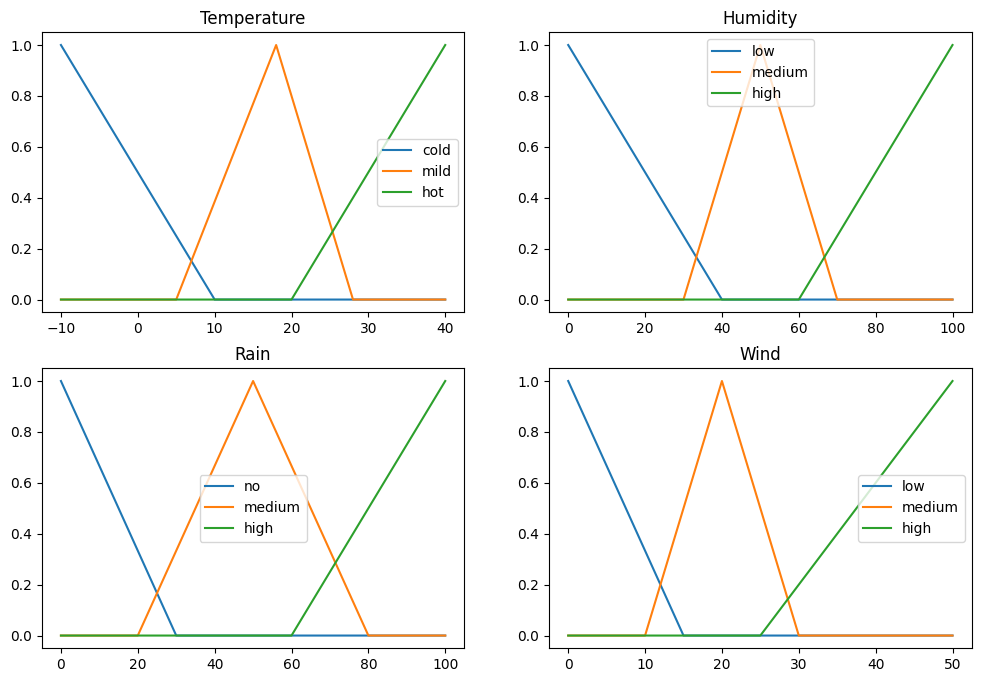

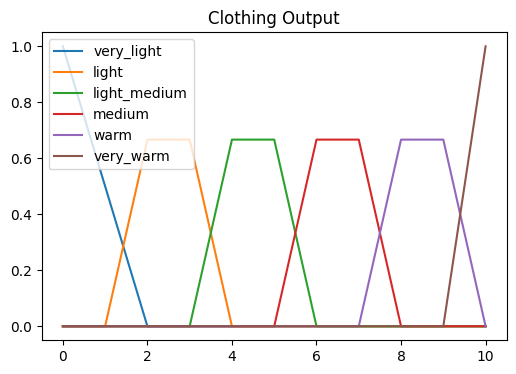

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for term in decision_agent.temperature.terms:
    axs[0, 0].plot(
        decision_agent.temperature.universe,
        decision_agent.temperature[term].mf,
        label=term
    )
axs[0, 0].set_title("Temperature")
axs[0, 0].legend()


for term in decision_agent.humidity.terms:
    axs[0, 1].plot(
        decision_agent.humidity.universe,
        decision_agent.humidity[term].mf,
        label=term
    )
axs[0, 1].set_title("Humidity")
axs[0, 1].legend()


for term in decision_agent.rain.terms:
    axs[1, 0].plot(
        decision_agent.rain.universe,
        decision_agent.rain[term].mf,
        label=term
    )
axs[1, 0].set_title("Rain")
axs[1, 0].legend()


for term in decision_agent.wind.terms:
    axs[1, 1].plot(
        decision_agent.wind.universe,
        decision_agent.wind[term].mf,
        label=term
    )
axs[1, 1].set_title("Wind")
axs[1, 1].legend()
plt.show()

plt.figure(figsize=(6, 4))
for term in decision_agent.clothing.terms:
    plt.plot(
        decision_agent.clothing.universe,
        decision_agent.clothing[term].mf,
        label=term
    )
plt.title("Clothing Output")
plt.legend()
plt.show()

## 2. Приклади
### 2.1 Демонстрація роботи системи на одному прикладі

In [17]:
weather = weather_agent.get_weather_data(
    temperature = 12,
    humidity = 70,
    rain = 60,
    wind = 20
)

score, recommendation = decision_agent.make_decision(weather)

print("Temperature:", weather["temperature"])
print("Humidity:", weather["humidity"])
print("Rain:", weather["rain"])
print("Wind:", weather["wind"])
print("Recommendation:", recommendation)

Temperature: 12
Humidity: 70
Rain: 60
Wind: 20
Recommendation: Прохолодна погода. Рекомендовано вдягнути куртку або тепле худі, теплі штани, закрите взуття. Бажано взяти парасолю. Можливий сильний вітер. Висока вологість може посилювати холод


### 2.2 Порівняння роботи системи на різних значеннях

In [ ]:
def weather_tests(n):

    results = []

    for _ in range(n):

        temperature = random.randint(-5, 35)
        humidity = random.randint(20, 100)
        rain = random.randint(0, 100)
        wind = random.randint(0, 40)

        weather = weather_agent.get_weather_data(
            temperature,
            humidity,
            rain,
            wind
        )

        score, recommendation = decision_agent.make_decision(
            weather
        )

        results.append({
            "temperature": temperature,
            "humidity": humidity,
            "rain": rain,
            "wind": wind,
            "score": score,
            "recommendation": recommendation.strip()
        })

    return pd.DataFrame(results)

In [ ]:
df = weather_tests(100)
print(df.head())

   temperature  humidity  rain  wind     score  \
0           25        52    15     8  4.890150   
1           23        32    81    19  5.651551   
2           -5        20    63    25  8.530216   
3           10        60    55    30  7.130458   
4           14        33    58    14  6.260417   

                                      recommendation  
0  Помірна погода. Рекомендовано вдягнути худі аб...  
1  Помірна погода. Рекомендовано вдягнути худі аб...  
2  Холодна погода. Рекомендовано вдягнути теплу к...  
3  Прохолодна погода. Рекомендовано вдягнути курт...  
4  Прохолодна погода. Рекомендовано вдягнути курт...  


## 3. Розробка web-інтерфейсу
### 3.1 Функція отримання рекомендації на основі вхідних даних

In [ ]:
def recommendation(temperature, humidity, rain, wind):

    weather = weather_agent.get_weather_data( temperature, humidity, rain, wind)
    score, recommendation = decision_agent.make_decision( weather)
    result = f"{recommendation} "

    return result

### 3.2 Інтерфейс

In [ ]:
with gr.Blocks() as demo:

    gr.Markdown(  " # Clothing Recommendation System " )

    with gr.Row(): 

        temperature = gr.Slider( minimum=-10, maximum=40,
                                value=15, label="Temperature (°C)" )
        humidity = gr.Slider( minimum=0, maximum=100,
                              value=50, label="Humidity (%)" )

    with gr.Row():

        rain = gr.Slider(minimum=0, maximum=100,
                         value=20, label="Rain Probability (%)" )
        wind = gr.Slider( minimum=0, maximum=50,
                          value=10,label="Wind Speed" )

    output = gr.Textbox(
        label = "Recommendation",
        lines = 2
    )

    predict_button = gr.Button(
        "Get Recommendation"
    )
    predict_button.click(
        fn = recommendation,
        inputs=[ temperature, humidity, rain, wind ],
        outputs=output
    )

demo.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
